In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader

### Get File path and load the csv data

In [46]:
from util.data_path import green_bean_price_avg as data_prices

In [47]:
wide = pd.read_csv(data_prices)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [48]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [49]:
SEQ_LEN = 12
PRED_LEN = 12

### Training the Transformer Model

In [50]:
from util.transformer_cust_class import SeqDataset, TransformerRegressor

In [51]:
series_scaled = train["scaled"].values.astype(np.float32)

ds = SeqDataset(series_scaled, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

model_tf = TransformerRegressor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_tf.parameters(), lr=1e-3)

In [52]:
EPOCHS = 500
for epoch in range(1, EPOCHS + 1):
    for xb, yb in loader:
        optimizer.zero_grad()
        y_pred = model_tf(xb)  # (B, 12)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} — loss = {loss.item():.6f}")


Epoch  50/500 — loss = 0.037713
Epoch 100/500 — loss = 0.031693
Epoch 150/500 — loss = 0.029110
Epoch 200/500 — loss = 0.026010
Epoch 250/500 — loss = 0.023913
Epoch 300/500 — loss = 0.021485
Epoch 350/500 — loss = 0.018745
Epoch 400/500 — loss = 0.017265
Epoch 450/500 — loss = 0.016735
Epoch 500/500 — loss = 0.015969


### Predict the data for the next year

In [53]:
model_tf.eval()
with torch.no_grad():
    window = (
        torch.tensor(series_scaled[-SEQ_LEN:], dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(-1)
    )
    tf_forecast_scaled = model_tf(window).squeeze(0).numpy()
    tf_forecast = scaler.inverse_transform(tf_forecast_scaled.reshape(-1, 1)).flatten()

tf_forecast = pd.Series(
    tf_forecast,
    index=pd.date_range("2024-01-01", periods=12, freq="MS"),
    name="TF_forecast",
)

### Compare The Error of a predicted data and the actual data in a table format

In [54]:
error = future["price"] - tf_forecast
abs_error = abs(error)
mae_tf = mean_absolute_error(future["price"], tf_forecast)
print(f"\nTransformer MAE 2567 = {mae_tf:.4f}")


error = pd.DataFrame(
    {
        "actual": future["price"],
        "tf_forecast": tf_forecast,
        "mae_tf": abs_error,
    }
)
print(error.round(3))
print(f"mean absolute error = {mae_tf:.4f}")


Transformer MAE 2567 = 2.0070
            actual  tf_forecast  mae_tf
2024-01-01   25.11    23.406000   1.704
2024-02-01   25.00    24.118999   0.881
2024-03-01   26.34    24.702999   1.637
2024-04-01   25.62    24.900000   0.720
2024-05-01   25.00    25.714001   0.714
2024-06-01   25.00    24.908001   0.092
2024-07-01   25.00    24.233999   0.766
2024-08-01   27.50    23.990000   3.510
2024-09-01   31.00    24.013000   6.987
2024-10-01   30.00    24.443001   5.557
2024-11-01   24.00    23.868999   0.131
2024-12-01   23.28    24.666000   1.386
mean absolute error = 2.0070


### Plot The predicted data compare to an actual data

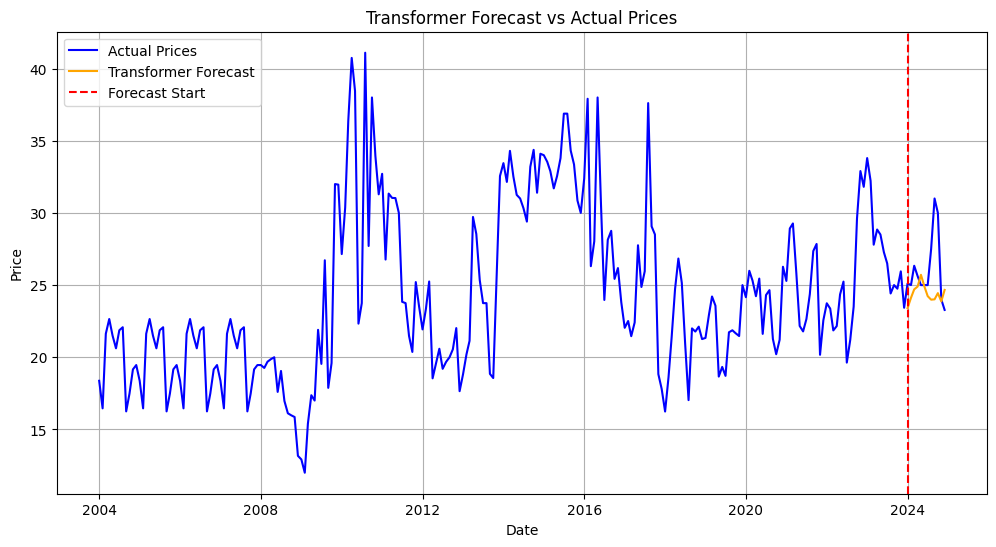

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(tf_forecast.index, tf_forecast, label="Transformer Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp("2024-01-01"), color="red", linestyle="--", label="Forecast Start"
)
plt.title("Transformer Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()